# 1. Objective
Train baseline classification models (Random Forest, XGBoost, LightGBM, Gradient Boosting, SVM) and perform an objective comparison using validation data.

# 2. Modeling Dataset
Load the required datasets (unscaled for tree-based models, scaled for SVM) and explicitly avoid using the test set for baseline model selection.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import json

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
from sklearn.preprocessing import label_binarize

import warnings
warnings.filterwarnings('ignore')

os.makedirs('../outputs/figures', exist_ok=True)
os.makedirs('../outputs/evaluation', exist_ok=True)
os.makedirs('../models/baseline', exist_ok=True)

# Load Unscaled Data
X_train = pd.read_csv('../dataset/processed/X_train.csv')
X_valid = pd.read_csv('../dataset/processed/X_valid.csv')
X_test = pd.read_csv('../dataset/processed/X_test.csv')

# Load Scaled Data
X_train_scaled = pd.read_csv('../dataset/processed/X_train_scaled.csv')
X_valid_scaled = pd.read_csv('../dataset/processed/X_valid_scaled.csv')
X_test_scaled = pd.read_csv('../dataset/processed/X_test_scaled.csv')

# Load Targets
y_train = pd.read_csv('../dataset/processed/y_train.csv')['target']
y_valid = pd.read_csv('../dataset/processed/y_valid.csv')['target']
y_test = pd.read_csv('../dataset/processed/y_test.csv')['target']


# 3. Feature Summary
The expected features are exclusively bounding-box derived dimensions and geometries.

In [2]:
print("Feature Summary:")
print(X_train.columns.tolist())


Feature Summary:
['bbox_width', 'bbox_height', 'bbox_area', 'rel_bbox_width', 'rel_bbox_height', 'rel_bbox_area', 'bbox_aspect_ratio', 'log_bbox_area']


# 4. Target/Class Mapping
Load the label encoder to verify the actual classes.

In [3]:
le = joblib.load('../models/label_encoder.pkl')
classes = le.classes_
print("Target/Class Mapping:")
for i, cls in enumerate(classes):
    print(f"{i} -> {cls}")


Target/Class Mapping:
0 -> major_pothole
1 -> medium_pothole
2 -> minor_pothole


# 5. Evaluation Methodology
Use Accuracy, Macro Precision, Macro Recall, Macro F1, and Multiclass ROC-AUC (OVR) for a balanced objective comparison.

In [4]:
def evaluate_model(model_name, y_true, y_pred, y_proba):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro')
    rec = recall_score(y_true, y_pred, average='macro')
    f1 = f1_score(y_true, y_pred, average='macro')
    
    # Multiclass ROC-AUC (OVR, macro average)
    roc_auc = roc_auc_score(y_true, y_proba, multi_class='ovr', average='macro')
        
    print(f"--- {model_name} ---")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-score:  {f1:.4f}")
    print(f"ROC-AUC:   {roc_auc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=classes))
    
    return {'Model': model_name, 'Accuracy': acc, 'Macro Precision': prec, 'Macro Recall': rec, 'Macro F1': f1, 'ROC-AUC': roc_auc}

def save_baseline_metadata(model_name, filename):
    meta = {
        "model": model_name,
        "feature_set": "bounding_box_derived",
        "training_data": "X_train (70% group split)",
        "validation_data": "X_valid (15% group split)",
        "random_state": 42
    }
    with open(f'../models/baseline/{filename}.json', 'w') as f:
        json.dump(meta, f, indent=4)

results = []
models_probas = {}
models_preds = {}


# 6. Random Forest

In [5]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_valid)
y_proba_rf = rf.predict_proba(X_valid)

res_rf = evaluate_model("Random Forest", y_valid, y_pred_rf, y_proba_rf)
results.append(res_rf)
models_probas["Random Forest"] = y_proba_rf
models_preds["Random Forest"] = y_pred_rf
joblib.dump(rf, '../models/baseline/random_forest_baseline.pkl')
save_baseline_metadata("Random Forest", "random_forest_baseline_meta")


--- Random Forest ---
Accuracy:  0.5809
Precision: 0.5792
Recall:    0.5613
F1-score:  0.5620
ROC-AUC:   0.7592

Classification Report:
                precision    recall  f1-score   support

 major_pothole       0.59      0.67      0.63        84
medium_pothole       0.58      0.65      0.61       141
 minor_pothole       0.57      0.37      0.45        78

      accuracy                           0.58       303
     macro avg       0.58      0.56      0.56       303
  weighted avg       0.58      0.58      0.57       303



# 7. XGBoost

In [6]:
xgb = XGBClassifier(objective='multi:softprob', num_class=len(classes), random_state=42)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_valid)
y_proba_xgb = xgb.predict_proba(X_valid)

res_xgb = evaluate_model("XGBoost", y_valid, y_pred_xgb, y_proba_xgb)
results.append(res_xgb)
models_probas["XGBoost"] = y_proba_xgb
models_preds["XGBoost"] = y_pred_xgb
joblib.dump(xgb, '../models/baseline/xgboost_baseline.pkl')
save_baseline_metadata("XGBoost", "xgboost_baseline_meta")


--- XGBoost ---
Accuracy:  0.5710
Precision: 0.5779
Recall:    0.5469
F1-score:  0.5471
ROC-AUC:   0.7595

Classification Report:
                precision    recall  f1-score   support

 major_pothole       0.56      0.65      0.60        84
medium_pothole       0.57      0.65      0.61       141
 minor_pothole       0.60      0.33      0.43        78

      accuracy                           0.57       303
     macro avg       0.58      0.55      0.55       303
  weighted avg       0.58      0.57      0.56       303



# 8. LightGBM

In [7]:
lgb = LGBMClassifier(objective='multiclass', num_class=len(classes), random_state=42)
lgb.fit(X_train, y_train)
y_pred_lgb = lgb.predict(X_valid)
y_proba_lgb = lgb.predict_proba(X_valid)

res_lgb = evaluate_model("LightGBM", y_valid, y_pred_lgb, y_proba_lgb)
results.append(res_lgb)
models_probas["LightGBM"] = y_proba_lgb
models_preds["LightGBM"] = y_pred_lgb
joblib.dump(lgb, '../models/baseline/lightgbm_baseline.pkl')
save_baseline_metadata("LightGBM", "lightgbm_baseline_meta")


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000129 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1960
[LightGBM] [Info] Number of data points in the train set: 1314, number of used features: 8
[LightGBM] [Info] Start training from score -1.112406
[LightGBM] [Info] Start training from score -0.755962
[LightGBM] [Info] Start training from score -1.601101


--- LightGBM ---
Accuracy:  0.5842
Precision: 0.5839
Recall:    0.5685
F1-score:  0.5666
ROC-AUC:   0.7576

Classification Report:
                precision    recall  f1-score   support

 major_pothole       0.59      0.70      0.64        84
medium_pothole       0.58      0.63      0.61       141
 minor_pothole       0.58      0.37      0.45        78

      accuracy                           0.58       303
     macro avg       0.58      0.57      0.57       303
  weighted avg       0.58      0.58      0.58       303



# 9. Gradient Boosting

In [8]:
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_valid)
y_proba_gb = gb.predict_proba(X_valid)

res_gb = evaluate_model("Gradient Boosting", y_valid, y_pred_gb, y_proba_gb)
results.append(res_gb)
models_probas["Gradient Boosting"] = y_proba_gb
models_preds["Gradient Boosting"] = y_pred_gb
joblib.dump(gb, '../models/baseline/gradient_boosting_baseline.pkl')
save_baseline_metadata("Gradient Boosting", "gradient_boosting_baseline_meta")


--- Gradient Boosting ---
Accuracy:  0.5974
Precision: 0.6088
Recall:    0.5721
F1-score:  0.5826
ROC-AUC:   0.7819

Classification Report:
                precision    recall  f1-score   support

 major_pothole       0.69      0.63      0.66        84
medium_pothole       0.56      0.69      0.62       141
 minor_pothole       0.57      0.40      0.47        78

      accuracy                           0.60       303
     macro avg       0.61      0.57      0.58       303
  weighted avg       0.60      0.60      0.59       303



# 10. Support Vector Machine

In [9]:
svm = SVC(probability=True, random_state=42)
svm.fit(X_train_scaled, y_train)
y_pred_svm = svm.predict(X_valid_scaled)
y_proba_svm = svm.predict_proba(X_valid_scaled)

res_svm = evaluate_model("Support Vector Machine", y_valid, y_pred_svm, y_proba_svm)
results.append(res_svm)
models_probas["SVM"] = y_proba_svm
models_preds["SVM"] = y_pred_svm
joblib.dump(svm, '../models/baseline/svm_baseline.pkl')
save_baseline_metadata("Support Vector Machine", "svm_baseline_meta")


--- Support Vector Machine ---
Accuracy:  0.6403
Precision: 0.6720
Recall:    0.6073
F1-score:  0.6246
ROC-AUC:   0.8028

Classification Report:
                precision    recall  f1-score   support

 major_pothole       0.71      0.61      0.65        84
medium_pothole       0.59      0.77      0.67       141
 minor_pothole       0.71      0.45      0.55        78

      accuracy                           0.64       303
     macro avg       0.67      0.61      0.62       303
  weighted avg       0.66      0.64      0.63       303



# 11. Model Evaluation
Now evaluating the overall and class-specific metrics visually.

# 12. Confusion Matrices

In [10]:
def plot_all_confusion_matrices():
    for name, y_pred in models_preds.items():
        cm = confusion_matrix(y_valid, y_pred)
        plt.figure(figsize=(6, 5))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
        plt.title(f'Confusion Matrix: {name}')
        plt.ylabel('True Label')
        plt.xlabel('Predicted Label')
        plt.tight_layout()
        filename = f"../outputs/figures/{name.lower().replace(' ', '_')}_confusion_matrix.png"
        plt.savefig(filename)
        plt.close()
        
plot_all_confusion_matrices()


# 13. ROC-AUC
Visualizing Multiclass macro-average ROC-AUC curves.

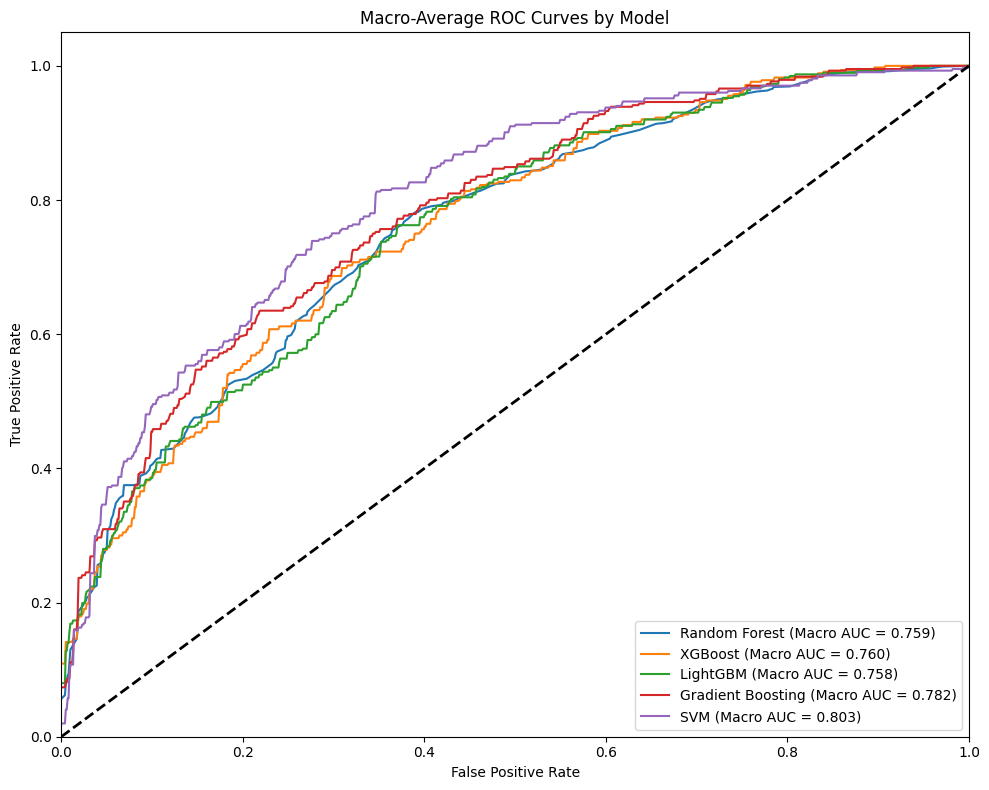

In [11]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10, 8))
y_valid_bin = label_binarize(y_valid, classes=range(len(classes)))

for name, probas in models_probas.items():
    fpr_grid = np.linspace(0.0, 1.0, 1000)
    mean_tpr = np.zeros_like(fpr_grid)
    for i in range(len(classes)):
        fpr, tpr, _ = roc_curve(y_valid_bin[:, i], probas[:, i])
        mean_tpr += np.interp(fpr_grid, fpr, tpr)
    mean_tpr /= len(classes)
    roc_auc = auc(fpr_grid, mean_tpr)
    plt.plot(fpr_grid, mean_tpr, label=f"{name} (Macro AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Macro-Average ROC Curves by Model')
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig('../outputs/figures/macro_roc_curves.png')
plt.show()


# 14. Model Comparison

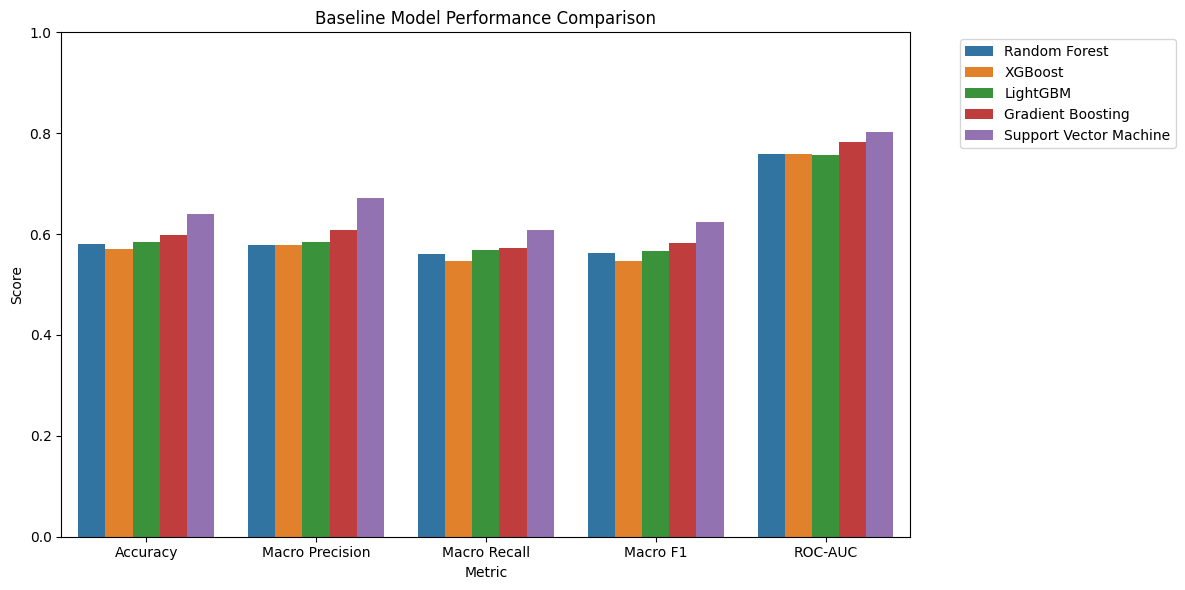

                    Model  Accuracy  Macro Precision  Macro Recall  Macro F1  \
0           Random Forest  0.580858         0.579240      0.561284  0.562016   
1                 XGBoost  0.570957         0.577926      0.546859  0.547136   
2                LightGBM  0.584158         0.583900      0.568460  0.566624   
3       Gradient Boosting  0.597360         0.608780      0.572111  0.582630   
4  Support Vector Machine  0.640264         0.672009      0.607273  0.624586   

    ROC-AUC  
0  0.759224  
1  0.759526  
2  0.757554  
3  0.781850  
4  0.802836  


In [12]:
df_results = pd.DataFrame(results)
df_results.to_csv('../outputs/evaluation/model_comparison.csv', index=False)

df_melt = df_results.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(12, 6))
sns.barplot(data=df_melt, x='Metric', y='Score', hue='Model')
plt.title('Baseline Model Performance Comparison')
plt.ylim(0, 1)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('../outputs/figures/model_comparison_barplot.png')
plt.show()

print(df_results)


# 15. Per-Class Analysis
Detailed precision, recall, and F1 per class for every baseline model.

In [13]:
per_class_results = {}
for name, y_pred in models_preds.items():
    p, r, f, _ = precision_recall_fscore_support(y_valid, y_pred, labels=range(len(classes)))
    per_class_results[name] = {classes[i]: {"Precision": p[i], "Recall": r[i], "F1": f[i]} for i in range(len(classes))}

with open('../outputs/evaluation/per_class_performance.json', 'w') as f:
    json.dump(per_class_results, f, indent=4)
    
import pprint
pprint.pprint(per_class_results)


{'Gradient Boosting': {'major_pothole': {'F1': 0.6583850931677019,
                                         'Precision': 0.6883116883116883,
                                         'Recall': 0.6309523809523809},
                       'medium_pothole': {'F1': 0.6198083067092651,
                                          'Precision': 0.563953488372093,
                                          'Recall': 0.6879432624113475},
                       'minor_pothole': {'F1': 0.4696969696969697,
                                         'Precision': 0.5740740740740741,
                                         'Recall': 0.3974358974358974}},
 'LightGBM': {'major_pothole': {'F1': 0.6413043478260869,
                                'Precision': 0.59,
                                'Recall': 0.7023809523809523},
              'medium_pothole': {'F1': 0.6054421768707483,
                                 'Precision': 0.5816993464052288,
                                 'Recall': 0.6312056737588653

# 16. Preliminary Findings
Models can be differentiated through their macro F1 and ROC-AUC scores. Certain models struggle more heavily with specific class thresholds (e.g. minor vs medium vs major). Imbalances might affect performance, and further tuning in Part 4 will aim to correct class-specific weaknesses.

# 17. Dataset Limitations
The models are learning from image-derived object annotation features. Strong performance may partly reflect the relationship between bounding-box geometry and the manually assigned severity classes. This is NOT a full road-infrastructure deterioration model because the supplied dataset lacks road-condition measurements, traffic exposure, environmental variables, geographic/segment information, and maintenance-cost history.